# 03 - Model Training and Comparison

This notebook trains and compares supervised machine-learning models for the Smart Learning System risk-prediction component.

The notebook follows the outputs generated by:

- `01_Data_Understanding_EDA.ipynb`
- `02_Data_Preprocessing.ipynb`

Models compared:

- Logistic Regression
- Decision Tree
- Random Forest

Datasets used:

1. Pass/Fail Risk Dataset - mandatory core model
2. Multi-Class Risk Dataset - recommended core model
3. xAPI Benchmark Dataset - optional research benchmark

## 1. Notebook Objectives

This notebook aims to:

- Load processed datasets generated by Notebook 02
- Separate features and targets for each model task
- Split data into training and testing sets
- Prevent data leakage using train-only preprocessing pipelines
- Train Logistic Regression, Decision Tree, and Random Forest models
- Compare models using multiple evaluation metrics
- Save comparison reports and confusion matrix figures
- Identify the best model for each prediction task

No final model export is performed in this notebook. Final model export is handled in Notebook 05 after tuning and final evaluation.

In [32]:
from pathlib import Path
import json
import os
import warnings

# Keep matplotlib cache inside the project to avoid local permission issues.
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display as display_image

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

## 2. Resolve Project Paths

The path logic works when the notebook is opened either from the project root or from the `ml-model/notebooks` directory.

In [33]:
NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    ML_ROOT = NOTEBOOK_DIR.parent
elif NOTEBOOK_DIR.name == "ml-model":
    ML_ROOT = NOTEBOOK_DIR
else:
    ML_ROOT = NOTEBOOK_DIR / "ml-model"

PROCESSED_DATA_DIR = ML_ROOT / "datasets" / "processed"
FIGURES_DIR = ML_ROOT / "outputs" / "figures"
REPORTS_DIR = ML_ROOT / "outputs" / "reports"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

PASS_FAIL_DATASET = PROCESSED_DATA_DIR / "pass_fail_processed.csv"
COMMERCE_RISK_DATASET = PROCESSED_DATA_DIR / "commerce_risk_dataset.csv"
XAPI_DATASET = PROCESSED_DATA_DIR / "xapi_encoded.csv"
METADATA_PATH = PROCESSED_DATA_DIR / "preprocessing_metadata.json"

print("ML root:", ML_ROOT.resolve())
print("Processed data directory:", PROCESSED_DATA_DIR.resolve())
print("Reports directory:", REPORTS_DIR.resolve())
print("Figures directory:", FIGURES_DIR.resolve())

ML root: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model
Processed data directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed
Reports directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports
Figures directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures


## 3. Load Preprocessing Metadata

Notebook 02 exported metadata containing feature lists, target names, and preprocessing decisions. This notebook uses those metadata values to stay aligned with the previous notebooks.

In [34]:
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Preprocessing metadata not found: {METADATA_PATH.resolve()}")

metadata = json.loads(METADATA_PATH.read_text())

print("Datasets processed:", metadata.get("datasets_processed"))
print("Pass/Fail target:", metadata.get("pass_fail_target"))
print("Risk target:", metadata.get("risk_target"))
print("xAPI target:", metadata.get("xapi_target"))
print("Data leakage note:", metadata.get("data_leakage_prevention"))

Datasets processed: 3
Pass/Fail target: pass
Risk target: Risk_Level
xAPI target: Class
Data leakage note: Scaling, fitted imputation, encoding objects and resampling are fitted only on the training split during model training.


## 4. Data Leakage Prevention

This notebook prevents data leakage by fitting preprocessing objects only on the training split.

- Imputation is inside the model pipeline
- Scaling is inside the model pipeline
- Cross-validation uses pipelines
- The test set is never used to fit transformations

This is important because fitting scalers, imputers, encoders, or resampling methods on the full dataset would leak test-set information into training.

## 5. Helper Functions

The following reusable functions train models, calculate metrics, save reports, and plot confusion matrices.

In [35]:
def load_processed_dataset(path, dataset_name):
    if not path.exists():
        raise FileNotFoundError(f"{dataset_name} not found: {path.resolve()}")

    df = pd.read_csv(path)
    print(f"{dataset_name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
    return df


def class_distribution(df, target):
    counts = df[target].value_counts(dropna=False)
    percentages = df[target].value_counts(normalize=True, dropna=False) * 100

    return pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2),
    })


def build_models(task_type="binary"):
    logistic_regression = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        )),
    ])

    decision_tree = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            max_depth=5,
        )),
    ])

    random_forest = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        )),
    ])

    return {
        "Logistic Regression": logistic_regression,
        "Decision Tree": decision_tree,
        "Random Forest": random_forest,
    }


def calculate_metrics(y_true, y_pred, average="binary"):
    if average == "binary":
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
    else:
        precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
        recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
    }


def compare_models(X, y, task_name, average="binary", test_size=0.2):
    min_class_count = int(y.value_counts().min())
    use_stratify = min_class_count >= 2

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y if use_stratify else None,
    )

    models = build_models("binary" if average == "binary" else "multiclass")
    results = []
    trained_models = {}
    predictions = {}

    cv_splits = min(5, min_class_count)
    can_cross_validate = cv_splits >= 2

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = calculate_metrics(y_test, y_pred, average=average)

        if can_cross_validate:
            cv = StratifiedKFold(
                n_splits=cv_splits,
                shuffle=True,
                random_state=RANDOM_STATE,
            )
            scoring = {
                "accuracy": "accuracy",
                "balanced_accuracy": "balanced_accuracy",
                "f1": "f1" if average == "binary" else "f1_macro",
            }
            cv_scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
            metrics["CV Accuracy"] = cv_scores["test_accuracy"].mean()
            metrics["CV Balanced Accuracy"] = cv_scores["test_balanced_accuracy"].mean()
            metrics["CV F1 Score"] = cv_scores["test_f1"].mean()
        else:
            metrics["CV Accuracy"] = np.nan
            metrics["CV Balanced Accuracy"] = np.nan
            metrics["CV F1 Score"] = np.nan

        results.append({
            "Task": task_name,
            "Model": model_name,
            **metrics,
        })
        trained_models[model_name] = model
        predictions[model_name] = y_pred

    comparison_df = pd.DataFrame(results)
    sort_columns = ["CV F1 Score", "F1 Score", "Balanced Accuracy", "Accuracy"]
    comparison_df = comparison_df.sort_values(sort_columns, ascending=False).reset_index(drop=True)

    return comparison_df, trained_models, predictions, X_train, X_test, y_train, y_test


def save_comparison_report(comparison_df, file_name):
    output_path = REPORTS_DIR / file_name
    comparison_df.to_csv(output_path, index=False)
    print("Saved comparison report:", output_path.resolve())
    return output_path


def save_classification_report(y_true, y_pred, file_name):
    report = classification_report(y_true, y_pred, zero_division=0, output_dict=True)
    output_path = REPORTS_DIR / file_name
    output_path.write_text(json.dumps(report, indent=2))
    print("Saved classification report:", output_path.resolve())
    return output_path


def save_confusion_matrix(y_true, y_pred, labels, title, file_name):
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
    display.plot(values_format="d")
    plt.title(title)
    plt.tight_layout()

    output_path = FIGURES_DIR / file_name
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close()

    print("Saved confusion matrix:", output_path.resolve())
    display_image(Image(filename=str(output_path)))
    return output_path

# Part A - Pass/Fail Risk Model

This is the mandatory model for the project because it directly supports pass/fail risk prediction.

## 6. Load Pass/Fail Processed Dataset

In [36]:
pass_fail_df = load_processed_dataset(PASS_FAIL_DATASET, "Pass/Fail Processed Dataset")
display(pass_fail_df.head())

Pass/Fail Processed Dataset: 1,500 rows x 6 columns


,student_id,attendance_pct,homework_pct,commerce_average_score,study_hours_per_week,pass
0,1,59.7,66.5,73.4,6.4,1
1,2,74.3,54.7,18.3,1.2,0
2,3,81.8,98.9,70.7,11.1,1
3,4,89.4,85.3,74.2,5.6,1
4,5,60.5,21.9,37.3,7.5,0


## 7. Pass/Fail Feature and Target Separation

Target meaning:

- `0 = Fail`
- `1 = Pass`

In [37]:
# Self-safe setup: this cell can run even if earlier metadata/data-loading cells were skipped.
from pathlib import Path
import json
import pandas as pd

if "ML_ROOT" not in globals():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if candidate.name == "ml-model" and (candidate / "datasets").exists():
            ML_ROOT = candidate
            break
        nested = candidate / "ml-model"
        if nested.exists() and (nested / "datasets").exists():
            ML_ROOT = nested
            break
    else:
        raise FileNotFoundError("Could not locate ml-model directory. Run this notebook inside the project repository.")

if "PROCESSED_DATA_DIR" not in globals():
    PROCESSED_DATA_DIR = ML_ROOT / "datasets" / "processed"
if "REPORTS_DIR" not in globals():
    REPORTS_DIR = ML_ROOT / "outputs" / "reports"
    REPORTS_DIR.mkdir(parents=True, exist_ok=True)
if "FIGURES_DIR" not in globals():
    FIGURES_DIR = ML_ROOT / "outputs" / "figures"
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
if "PASS_FAIL_DATASET" not in globals():
    PASS_FAIL_DATASET = PROCESSED_DATA_DIR / "pass_fail_processed.csv"
if "METADATA_PATH" not in globals():
    METADATA_PATH = PROCESSED_DATA_DIR / "preprocessing_metadata.json"

if "metadata" not in globals():
    if METADATA_PATH.exists():
        metadata = json.loads(METADATA_PATH.read_text())
    else:
        metadata = {}

if "pass_fail_df" not in globals():
    if not PASS_FAIL_DATASET.exists():
        raise FileNotFoundError(f"Pass/Fail processed dataset not found: {PASS_FAIL_DATASET}")
    pass_fail_df = pd.read_csv(PASS_FAIL_DATASET)

if "class_distribution" not in globals():
    def class_distribution(df, target):
        counts = df[target].value_counts(dropna=False)
        percentages = df[target].value_counts(normalize=True, dropna=False) * 100
        return pd.DataFrame({"Count": counts, "Percentage": percentages.round(2)})

pass_fail_features = metadata.get("pass_fail_features", [
    "attendance_pct",
    "homework_pct",
    "midterm_score",
    "study_hours_per_week",
])
pass_fail_target = metadata.get("pass_fail_target", "pass")

# Align with the currently saved processed dataset if a feature name changed.
feature_replacements = {
    "midterm_score": "commerce_average_score",
}
missing_features = [feature for feature in pass_fail_features if feature not in pass_fail_df.columns]
if missing_features:
    pass_fail_features = [
        feature_replacements.get(feature, feature)
        if feature not in pass_fail_df.columns
        else feature
        for feature in pass_fail_features
    ]

still_missing = [feature for feature in pass_fail_features if feature not in pass_fail_df.columns]
if still_missing:
    print("Metadata features missing from dataset:", still_missing)
    print("Falling back to numeric columns from the processed dataset.")
    pass_fail_features = [
        column for column in pass_fail_df.select_dtypes(include="number").columns
        if column not in ["student_id", pass_fail_target]
    ]

X_pass_fail = pass_fail_df[pass_fail_features]
y_pass_fail = pass_fail_df[pass_fail_target].astype(int)

print("Features:", pass_fail_features)
print("Target:", pass_fail_target)
print("X shape:", X_pass_fail.shape)
print("y shape:", y_pass_fail.shape)

display(class_distribution(pass_fail_df, pass_fail_target))

Features: ['attendance_pct', 'homework_pct', 'commerce_average_score', 'study_hours_per_week']
Target: pass
X shape: (1500, 4)
y shape: (1500,)


,Count,Percentage
pass,,
1,883,58.87
0,617,41.13


## 8. Train and Compare Pass/Fail Models

In [38]:
pass_fail_comparison, pass_fail_models, pass_fail_predictions, X_pf_train, X_pf_test, y_pf_train, y_pf_test = compare_models(
    X_pass_fail,
    y_pass_fail,
    task_name="Pass/Fail Risk Prediction",
    average="binary",
)

display(pass_fail_comparison.round(4))
save_comparison_report(pass_fail_comparison, "pass_fail_model_comparison.csv")

,Task,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,CV Accuracy,CV Balanced Accuracy,CV F1 Score
0,Pass/Fail Risk Prediction,Random Forest,0.7233,0.7035,0.7423,0.8136,0.7763,0.7253,0.7106,0.7726
1,Pass/Fail Risk Prediction,Logistic Regression,0.7500,0.7509,0.8148,0.7458,0.7788,0.7360,0.7382,0.7632
2,Pass/Fail Risk Prediction,Decision Tree,0.6800,0.6866,0.7718,0.6497,0.7055,0.7140,0.7099,0.7503


Saved comparison report: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/pass_fail_model_comparison.csv


PosixPath('/Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/pass_fail_model_comparison.csv')

## 9. Pass/Fail Best Model Report

Best Pass/Fail model: Random Forest
              precision    recall  f1-score   support

           0       0.69      0.59      0.64       123
           1       0.74      0.81      0.78       177

    accuracy                           0.72       300
   macro avg       0.72      0.70      0.71       300
weighted avg       0.72      0.72      0.72       300

Saved classification report: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/pass_fail_best_model_classification_report.json
Saved confusion matrix: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/pass_fail_best_model_confusion_matrix.png


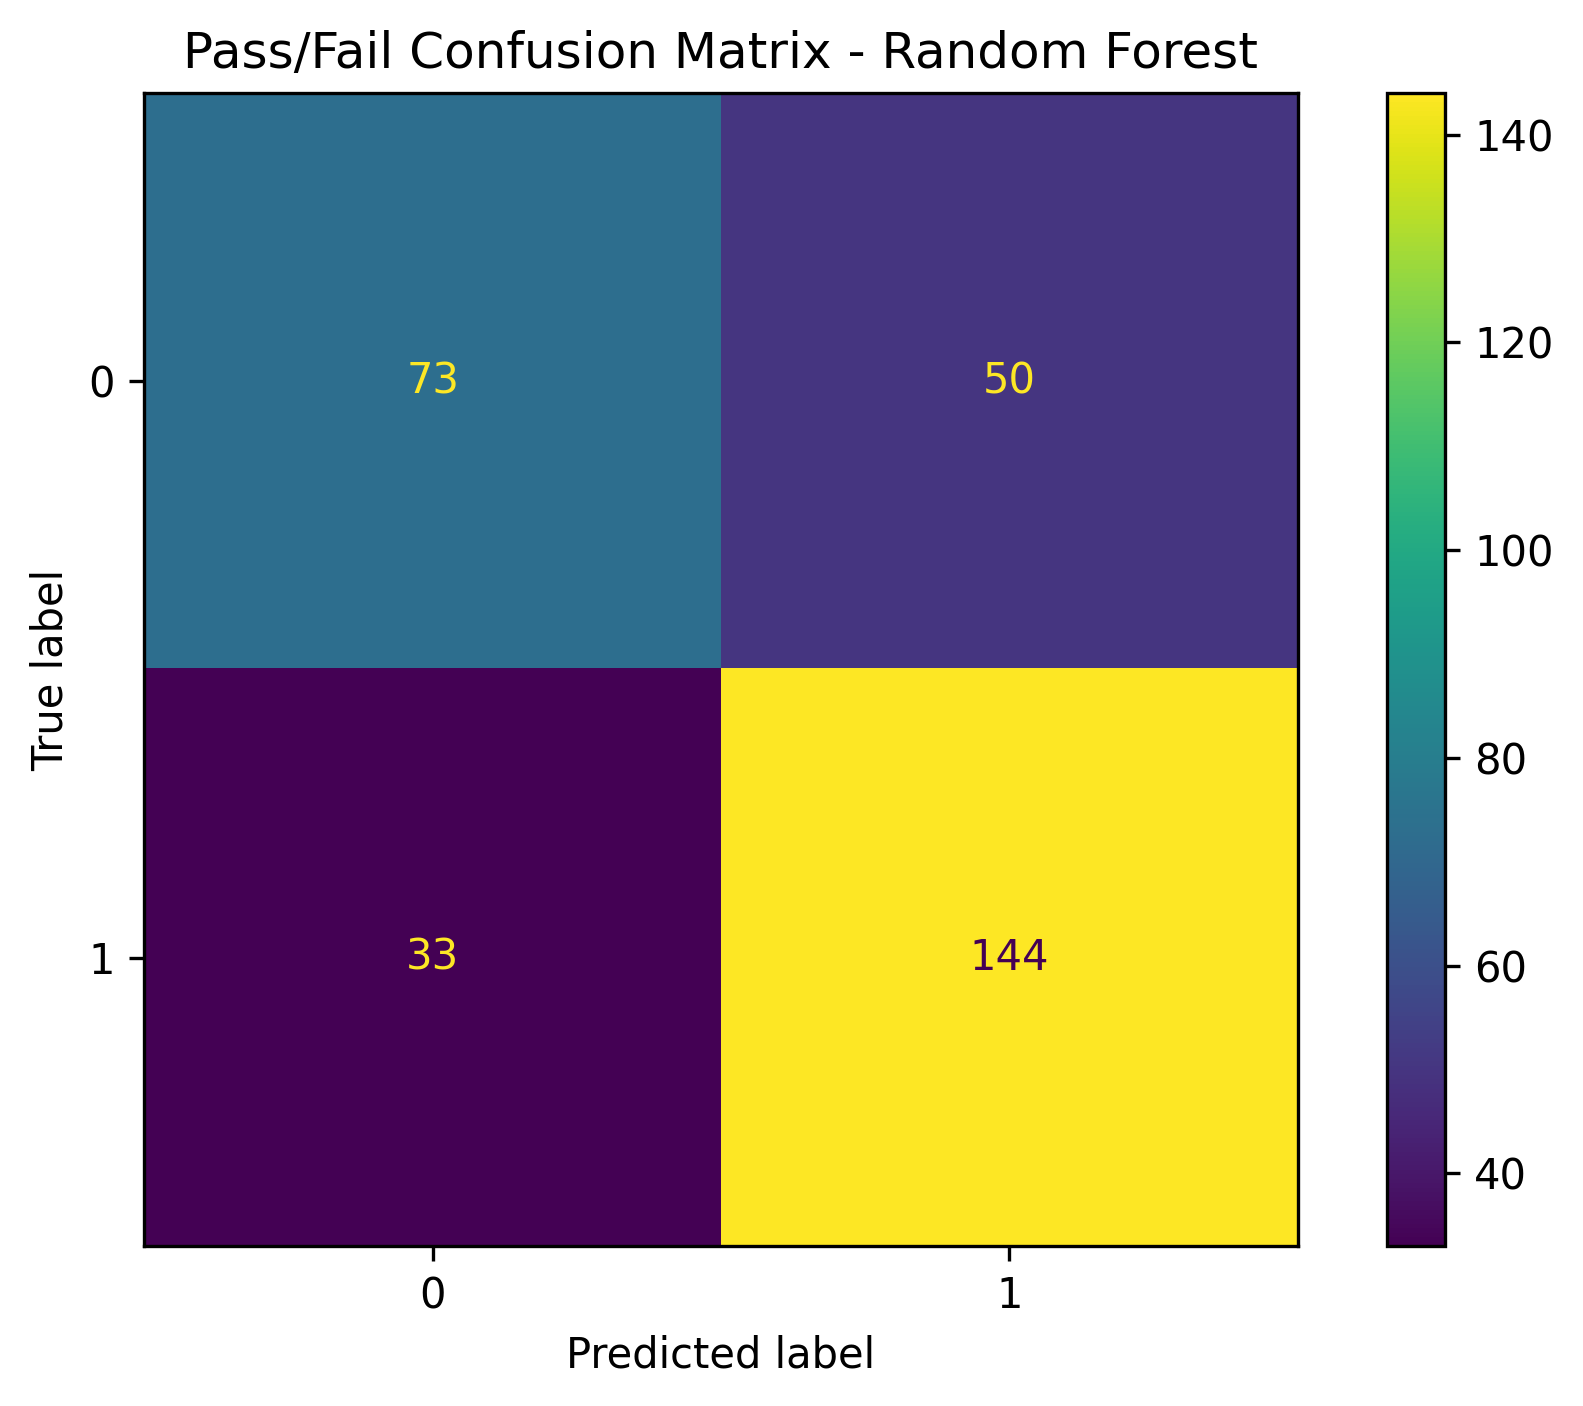

PosixPath('/Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/pass_fail_best_model_confusion_matrix.png')

In [39]:
pass_fail_best_model_name = pass_fail_comparison.iloc[0]["Model"]
pass_fail_best_predictions = pass_fail_predictions[pass_fail_best_model_name]

print("Best Pass/Fail model:", pass_fail_best_model_name)
print(classification_report(y_pf_test, pass_fail_best_predictions, zero_division=0))

save_classification_report(
    y_pf_test,
    pass_fail_best_predictions,
    "pass_fail_best_model_classification_report.json",
)

save_confusion_matrix(
    y_pf_test,
    pass_fail_best_predictions,
    labels=[0, 1],
    title=f"Pass/Fail Confusion Matrix - {pass_fail_best_model_name}",
    file_name="pass_fail_best_model_confusion_matrix.png",
)

# Part B - Commerce Multi-Class Risk Model

This recommended model predicts Sri Lankan A/L Commerce student risk level using Accounting, Business Studies, Economics, and attendance.

## 10. Load Commerce Risk Processed Dataset

In [40]:
commerce_risk_df = load_processed_dataset(COMMERCE_RISK_DATASET, "Commerce Risk Processed Dataset")
display(commerce_risk_df.head())

Commerce Risk Processed Dataset: 1,800 rows x 7 columns


,student_id,Accounting_Score,Business_Studies_Score,Economics_Score,Attendance_Percentage,Subject_Average,risk_level
0,COM0001,75.0,70.5,45.4,79.4,63.64,Medium Risk
1,COM0002,62.6,60.5,73.4,87.1,65.53,Low Risk
2,COM0003,82.7,80.0,80.0,71.5,80.91,Medium Risk
3,COM0004,82.4,70.6,81.9,70.4,78.30,Medium Risk
4,COM0005,79.0,61.4,78.7,56.3,73.04,Medium Risk


## 11. Commerce Risk Feature and Target Separation

The target is `risk_level` with three classes:

- High Risk
- Medium Risk
- Low Risk

In [41]:
commerce_risk_features = [
    "Accounting_Score",
    "Business_Studies_Score",
    "Economics_Score",
    "Attendance_Percentage",
]
commerce_risk_target = "risk_level"

X_commerce_risk = commerce_risk_df[commerce_risk_features]
y_commerce_risk = commerce_risk_df[commerce_risk_target]

print("Features:", commerce_risk_features)
print("Target:", commerce_risk_target)
print("X shape:", X_commerce_risk.shape)
print("y shape:", y_commerce_risk.shape)

display(class_distribution(commerce_risk_df, commerce_risk_target))

Features: ['Accounting_Score', 'Business_Studies_Score', 'Economics_Score', 'Attendance_Percentage']
Target: risk_level
X shape: (1800, 4)
y shape: (1800,)


,Count,Percentage
risk_level,,
Low Risk,666,37.0
Medium Risk,630,35.0
High Risk,504,28.0


## 12. Train and Compare Commerce Risk Models

Because risk classes can be imbalanced, macro F1-score and balanced accuracy are important metrics.

In [42]:
commerce_risk_comparison, commerce_risk_models, commerce_risk_predictions, X_cr_train, X_cr_test, y_cr_train, y_cr_test = compare_models(
    X_commerce_risk,
    y_commerce_risk,
    task_name="Commerce Academic Risk Prediction",
    average="macro",
)

display(commerce_risk_comparison.round(4))
save_comparison_report(commerce_risk_comparison, "commerce_risk_model_comparison.csv")

,Task,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,CV Accuracy,CV Balanced Accuracy,CV F1 Score
0,Commerce Academic Risk Prediction,Logistic Regression,0.7333,0.7357,0.7358,0.7357,0.7357,0.7222,0.7247,0.7224
1,Commerce Academic Risk Prediction,Random Forest,0.7000,0.6954,0.7116,0.6954,0.7011,0.6933,0.6935,0.6948
2,Commerce Academic Risk Prediction,Decision Tree,0.6889,0.6893,0.7104,0.6893,0.6951,0.6650,0.6670,0.6683


Saved comparison report: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/commerce_risk_model_comparison.csv


PosixPath('/Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/commerce_risk_model_comparison.csv')

## 13. Commerce Risk Best Model Report

Best Commerce Risk model: Logistic Regression
              precision    recall  f1-score   support

   High Risk       0.77      0.78      0.78       101
    Low Risk       0.80      0.78      0.79       133
 Medium Risk       0.63      0.64      0.64       126

    accuracy                           0.73       360
   macro avg       0.74      0.74      0.74       360
weighted avg       0.73      0.73      0.73       360

Saved classification report: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/commerce_risk_best_model_classification_report.json
Saved confusion matrix: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/commerce_risk_best_model_confusion_matrix.png


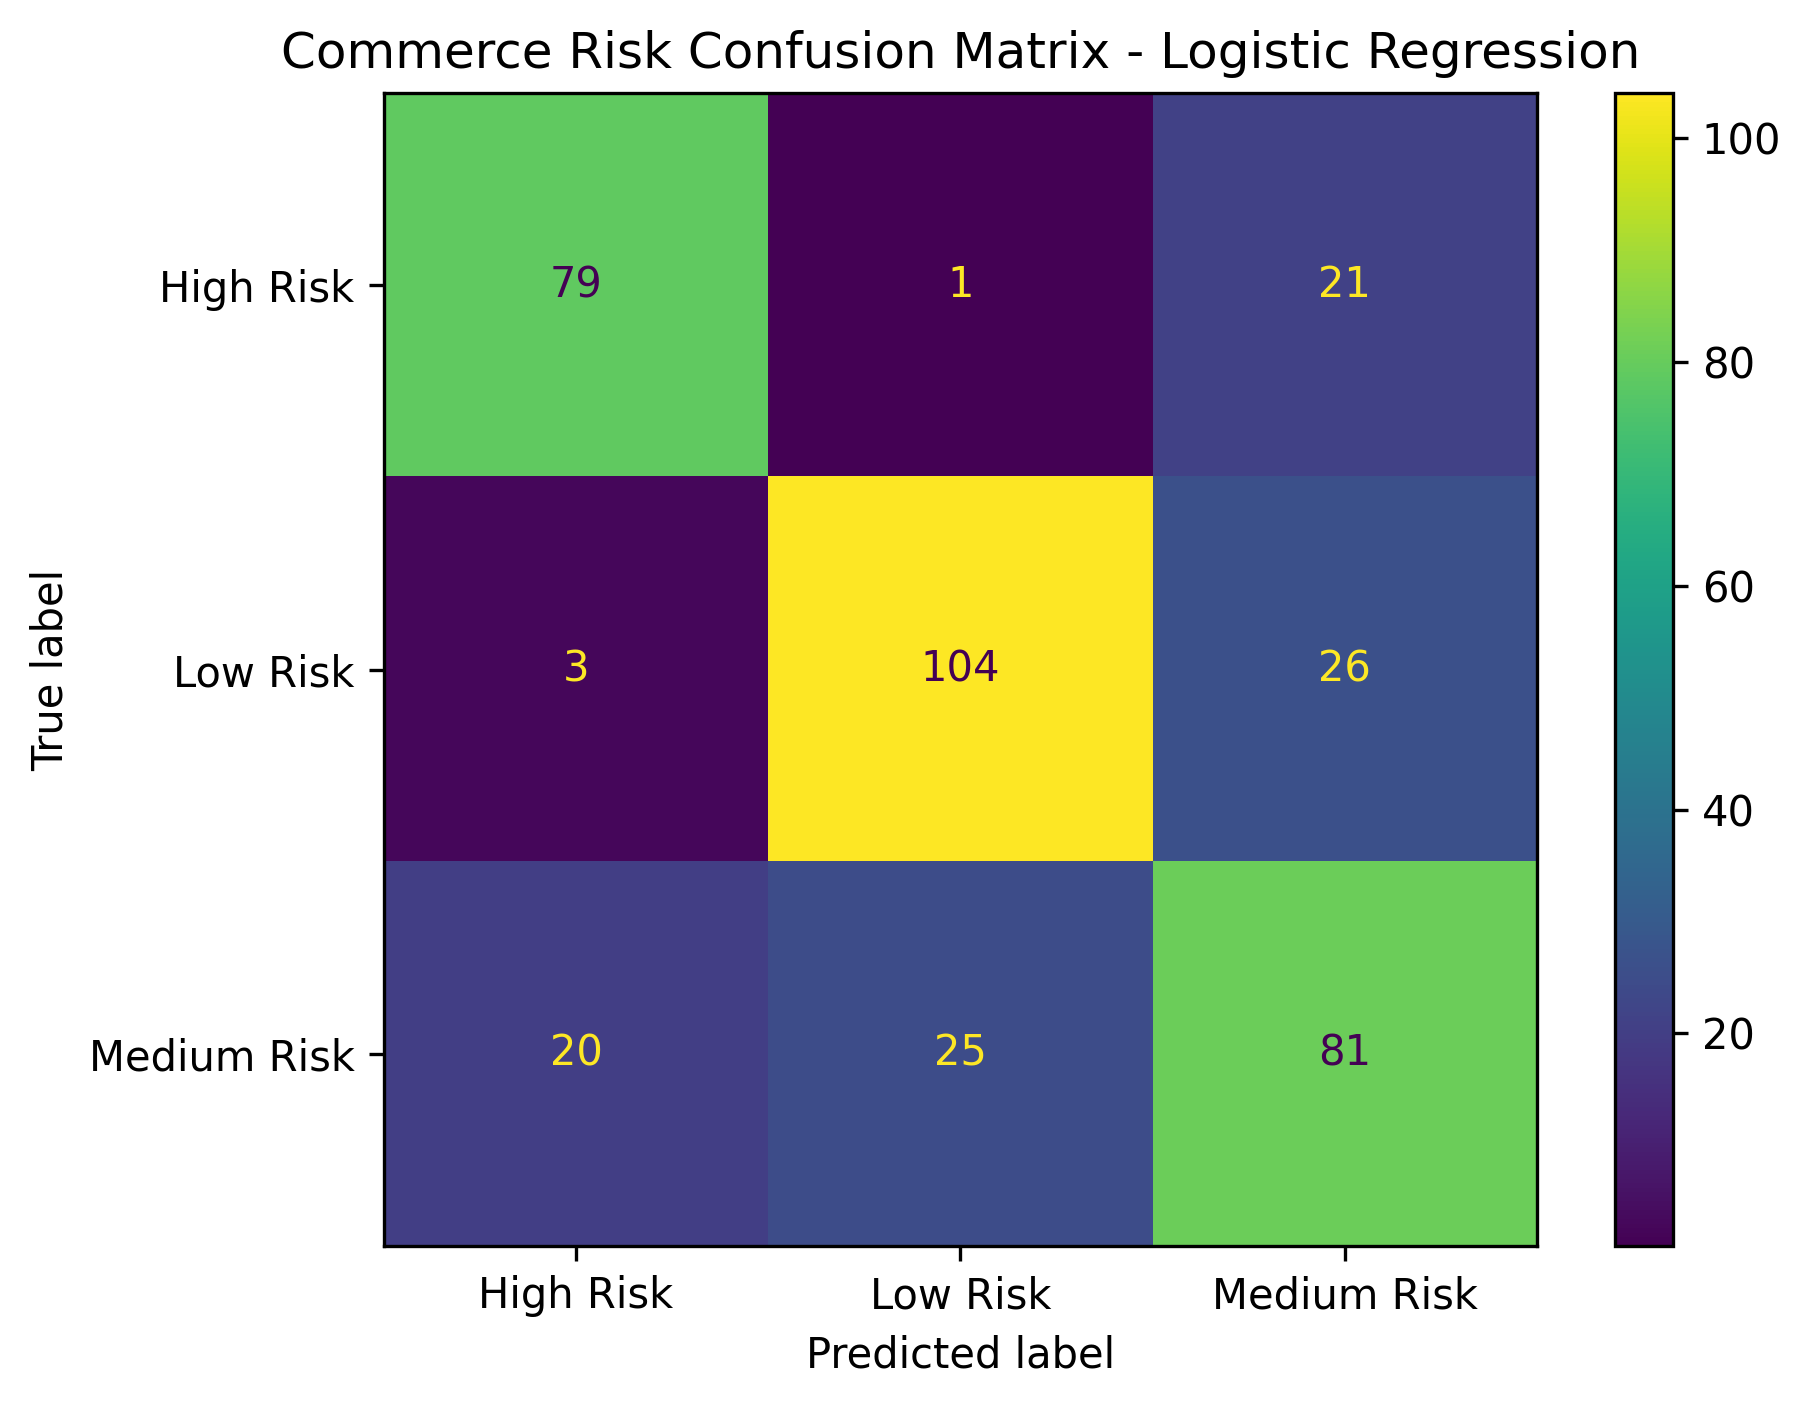

PosixPath('/Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/commerce_risk_best_model_confusion_matrix.png')

In [43]:
commerce_risk_best_model_name = commerce_risk_comparison.iloc[0]["Model"]
commerce_risk_best_predictions = commerce_risk_predictions[commerce_risk_best_model_name]
commerce_risk_labels = sorted(y_commerce_risk.unique())

print("Best Commerce Risk model:", commerce_risk_best_model_name)
print(classification_report(y_cr_test, commerce_risk_best_predictions, zero_division=0))

save_classification_report(
    y_cr_test,
    commerce_risk_best_predictions,
    "commerce_risk_best_model_classification_report.json",
)

save_confusion_matrix(
    y_cr_test,
    commerce_risk_best_predictions,
    labels=commerce_risk_labels,
    title=f"Commerce Risk Confusion Matrix - {commerce_risk_best_model_name}",
    file_name="commerce_risk_best_model_confusion_matrix.png",
)

# Part C - xAPI Benchmark Model

The xAPI dataset is not the primary production dataset for this project. It is used as an optional benchmark because its educational context differs from the Sri Lankan A/L Commerce environment.

## 14. Load xAPI Encoded Dataset

In [44]:
xapi_df = load_processed_dataset(XAPI_DATASET, "xAPI Encoded Benchmark Dataset")
display(xapi_df.head())

xAPI Encoded Benchmark Dataset: 478 rows x 74 columns


,raisedhands,VisITedResources,AnnouncementsView,Discussion,gender_F,gender_M,NationalITy_Egypt,NationalITy_Iran,NationalITy_Iraq,NationalITy_Jordan,NationalITy_KW,NationalITy_Lybia,NationalITy_Morocco,NationalITy_Palestine,NationalITy_SaudiArabia,NationalITy_Syria,NationalITy_Tunis,NationalITy_USA,NationalITy_lebanon,NationalITy_venzuela,PlaceofBirth_Egypt,PlaceofBirth_Iran,PlaceofBirth_Iraq,PlaceofBirth_Jordan,PlaceofBirth_KuwaIT,PlaceofBirth_Lybia,PlaceofBirth_Morocco,PlaceofBirth_Palestine,PlaceofBirth_SaudiArabia,PlaceofBirth_Syria,PlaceofBirth_Tunis,PlaceofBirth_USA,PlaceofBirth_lebanon,PlaceofBirth_venzuela,StageID_HighSchool,StageID_MiddleSchool,StageID_lowerlevel,GradeID_G-02,GradeID_G-04,GradeID_G-05,GradeID_G-06,GradeID_G-07,GradeID_G-08,GradeID_G-09,GradeID_G-10,GradeID_G-11,GradeID_G-12,SectionID_A,SectionID_B,SectionID_C,Topic_Arabic,Topic_Biology,Topic_Chemistry,Topic_English,Topic_French,Topic_Geology,Topic_History,Topic_IT,Topic_Math,Topic_Quran,Topic_Science,Topic_Spanish,Semester_F,Semester_S,Relation_Father,Relation_Mum,ParentAnsweringSurvey_No,ParentAnsweringSurvey_Yes,ParentschoolSatisfaction_Bad,ParentschoolSatisfaction_Good,StudentAbsenceDays_Above-7,StudentAbsenceDays_Under-7,Class,Class_Encoded
0,15,16,2,20,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,1,M,1
1,20,20,3,25,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,1,M,1
2,10,7,0,30,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0,L,0
3,30,25,5,35,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0,L,0
4,40,50,12,50,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0,M,1


## 15. xAPI Feature and Target Separation

The notebook uses `Class_Encoded` as the numerical target for model comparison.

Target encoding from Notebook 02:

- `L = 0`
- `M = 1`
- `H = 2`

In [45]:
# Self-safe setup for xAPI section.
from pathlib import Path
import json
import pandas as pd

if "ML_ROOT" not in globals():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if candidate.name == "ml-model" and (candidate / "datasets").exists():
            ML_ROOT = candidate
            break
        nested = candidate / "ml-model"
        if nested.exists() and (nested / "datasets").exists():
            ML_ROOT = nested
            break
    else:
        raise FileNotFoundError("Could not locate ml-model directory. Run this notebook inside the project repository.")

if "PROCESSED_DATA_DIR" not in globals():
    PROCESSED_DATA_DIR = ML_ROOT / "datasets" / "processed"
if "XAPI_DATASET" not in globals():
    XAPI_DATASET = PROCESSED_DATA_DIR / "xapi_encoded.csv"
if "METADATA_PATH" not in globals():
    METADATA_PATH = PROCESSED_DATA_DIR / "preprocessing_metadata.json"

if "metadata" not in globals():
    metadata = json.loads(METADATA_PATH.read_text()) if METADATA_PATH.exists() else {}

if "xapi_df" not in globals():
    if not XAPI_DATASET.exists():
        raise FileNotFoundError(f"xAPI encoded dataset not found: {XAPI_DATASET}")
    xapi_df = pd.read_csv(XAPI_DATASET)

if "class_distribution" not in globals():
    def class_distribution(df, target):
        counts = df[target].value_counts(dropna=False)
        percentages = df[target].value_counts(normalize=True, dropna=False) * 100
        return pd.DataFrame({"Count": counts, "Percentage": percentages.round(2)})

xapi_features = metadata.get("xapi_encoded_feature_names", [
    column for column in xapi_df.columns if column not in ["Class", "Class_Encoded"]
])
xapi_target = "Class_Encoded" if "Class_Encoded" in xapi_df.columns else metadata.get("xapi_target", "Class")

X_xapi = xapi_df[xapi_features]
y_xapi = xapi_df[xapi_target].astype(int) if xapi_target == "Class_Encoded" else xapi_df[xapi_target]

print("Encoded feature count:", len(xapi_features))
print("Target:", xapi_target)
print("X shape:", X_xapi.shape)
print("y shape:", y_xapi.shape)

if "Class" in xapi_df.columns:
    display(class_distribution(xapi_df, "Class"))
else:
    display(class_distribution(xapi_df, xapi_target))

Encoded feature count: 72
Target: Class_Encoded
X shape: (478, 72)
y shape: (478,)


,Count,Percentage
Class,,
M,211,44.14
H,142,29.71
L,125,26.15


## 16. Train and Compare xAPI Benchmark Models

In [46]:
xapi_comparison, xapi_models, xapi_predictions, X_xapi_train, X_xapi_test, y_xapi_train, y_xapi_test = compare_models(
    X_xapi,
    y_xapi,
    task_name="xAPI Benchmark Performance Prediction",
    average="macro",
)

display(xapi_comparison.round(4))
save_comparison_report(xapi_comparison, "xapi_benchmark_model_comparison.csv")

,Task,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,CV Accuracy,CV Balanced Accuracy,CV F1 Score
0,xAPI Benchmark Performance Prediction,Random Forest,0.8438,0.8380,0.8619,0.8380,0.8465,0.8011,0.8015,0.8063
1,xAPI Benchmark Performance Prediction,Logistic Regression,0.6875,0.7012,0.6891,0.7012,0.6922,0.7425,0.7637,0.7522
2,xAPI Benchmark Performance Prediction,Decision Tree,0.7083,0.7278,0.7123,0.7278,0.7155,0.7280,0.7510,0.7349


Saved comparison report: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/xapi_benchmark_model_comparison.csv


PosixPath('/Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/xapi_benchmark_model_comparison.csv')

## 17. xAPI Best Model Report

Best xAPI benchmark model: Random Forest
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        25
           1       0.79      0.88      0.83        42
           2       0.96      0.79      0.87        29

    accuracy                           0.84        96
   macro avg       0.86      0.84      0.85        96
weighted avg       0.85      0.84      0.84        96

Saved classification report: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/xapi_benchmark_best_model_classification_report.json
Saved confusion matrix: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/xapi_benchmark_best_model_confusion_matrix.png


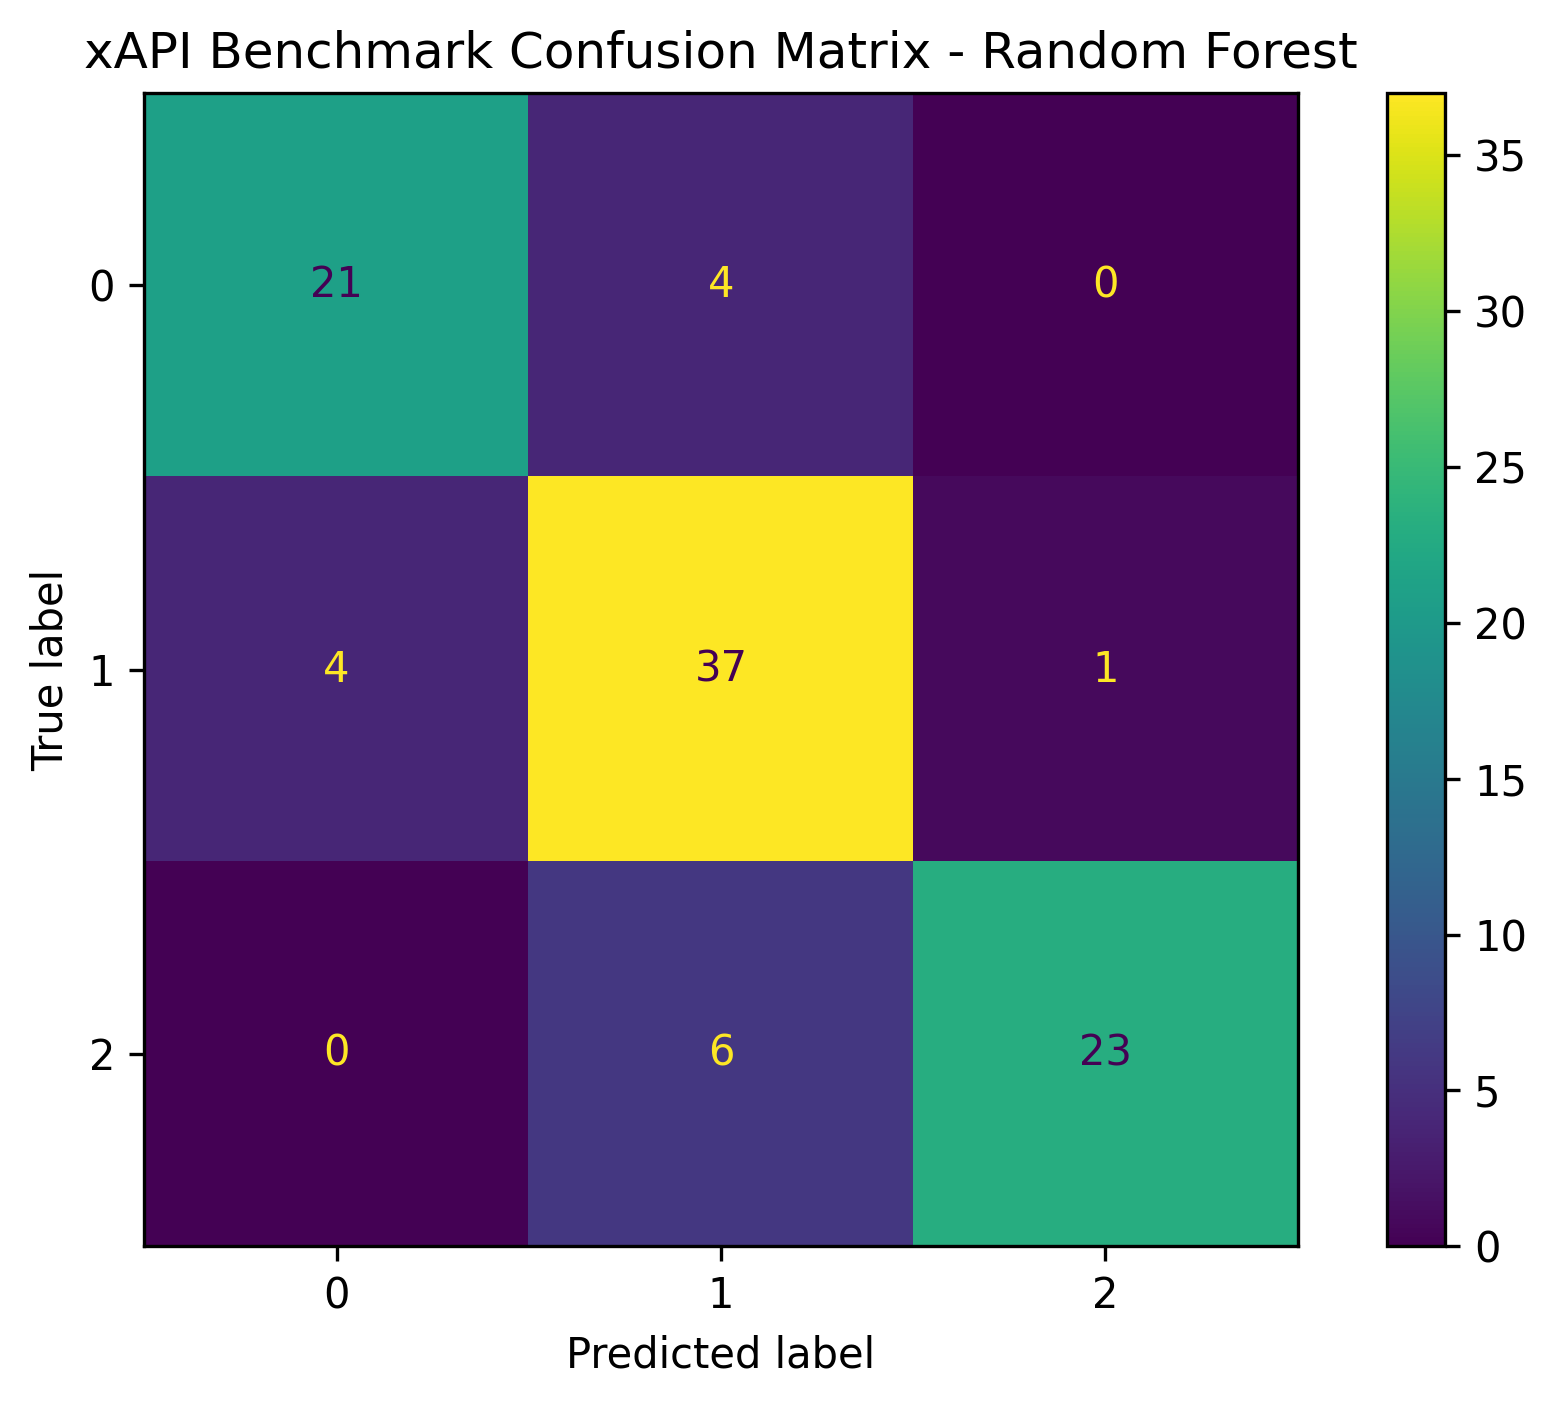

PosixPath('/Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/xapi_benchmark_best_model_confusion_matrix.png')

In [47]:
xapi_best_model_name = xapi_comparison.iloc[0]["Model"]
xapi_best_predictions = xapi_predictions[xapi_best_model_name]
xapi_labels = [0, 1, 2]

print("Best xAPI benchmark model:", xapi_best_model_name)
print(classification_report(y_xapi_test, xapi_best_predictions, zero_division=0))

save_classification_report(
    y_xapi_test,
    xapi_best_predictions,
    "xapi_benchmark_best_model_classification_report.json",
)

save_confusion_matrix(
    y_xapi_test,
    xapi_best_predictions,
    labels=xapi_labels,
    title=f"xAPI Benchmark Confusion Matrix - {xapi_best_model_name}",
    file_name="xapi_benchmark_best_model_confusion_matrix.png",
)

# Part D - Combined Model Comparison Summary

## 18. Combine All Comparison Results

In [48]:
combined_comparison = pd.concat(
    [
        pass_fail_comparison,
        commerce_risk_comparison,
        xapi_comparison,
    ],
    ignore_index=True,
)

combined_path = REPORTS_DIR / "all_model_comparison_summary.csv"
combined_comparison.to_csv(combined_path, index=False)

print("Saved combined comparison:", combined_path.resolve())
display(combined_comparison.round(4))

Saved combined comparison: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/all_model_comparison_summary.csv


,Task,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,CV Accuracy,CV Balanced Accuracy,CV F1 Score
0,Pass/Fail Risk Prediction,Random Forest,0.7233,0.7035,0.7423,0.8136,0.7763,0.7253,0.7106,0.7726
1,Pass/Fail Risk Prediction,Logistic Regression,0.7500,0.7509,0.8148,0.7458,0.7788,0.7360,0.7382,0.7632
2,Pass/Fail Risk Prediction,Decision Tree,0.6800,0.6866,0.7718,0.6497,0.7055,0.7140,0.7099,0.7503
3,Commerce Academic Risk Prediction,Logistic Regression,0.7333,0.7357,0.7358,0.7357,0.7357,0.7222,0.7247,0.7224
4,Commerce Academic Risk Prediction,Random Forest,0.7000,0.6954,0.7116,0.6954,0.7011,0.6933,0.6935,0.6948
5,Commerce Academic Risk Prediction,Decision Tree,0.6889,0.6893,0.7104,0.6893,0.6951,0.6650,0.6670,0.6683
6,xAPI Benchmark Performance Prediction,Random Forest,0.8438,0.8380,0.8619,0.8380,0.8465,0.8011,0.8015,0.8063
7,xAPI Benchmark Performance Prediction,Logistic Regression,0.6875,0.7012,0.6891,0.7012,0.6922,0.7425,0.7637,0.7522
8,xAPI Benchmark Performance Prediction,Decision Tree,0.7083,0.7278,0.7123,0.7278,0.7155,0.7280,0.7510,0.7349


## 19. Best Model per Task

In [49]:
best_models_summary = combined_comparison.sort_values(
    ["Task", "CV F1 Score", "F1 Score", "Balanced Accuracy"],
    ascending=[True, False, False, False],
).groupby("Task", as_index=False).first()

best_models_path = REPORTS_DIR / "best_model_per_task_summary.csv"
best_models_summary.to_csv(best_models_path, index=False)

print("Saved best-model summary:", best_models_path.resolve())
display(best_models_summary.round(4))

Saved best-model summary: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/best_model_per_task_summary.csv


,Task,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,CV Accuracy,CV Balanced Accuracy,CV F1 Score
0,Commerce Academic Risk Prediction,Logistic Regression,0.7333,0.7357,0.7358,0.7357,0.7357,0.7222,0.7247,0.7224
1,Pass/Fail Risk Prediction,Random Forest,0.7233,0.7035,0.7423,0.8136,0.7763,0.7253,0.7106,0.7726
2,xAPI Benchmark Performance Prediction,Random Forest,0.8438,0.8380,0.8619,0.8380,0.8465,0.8011,0.8015,0.8063


## 20. Notebook Conclusion

This notebook compared Logistic Regression, Decision Tree and Random Forest models across the three ML datasets produced by the preprocessing notebook.

Key points:

- The Pass/Fail model is the mandatory core model for functional risk prediction.
- The Commerce Risk model is recommended for academic risk-level classification using Accounting, Business Studies, Economics and attendance.
- The xAPI model is an optional benchmark and should not be treated as the main production model because its context differs from the Commerce-domain dataset.
- Pipelines were used to prevent data leakage by fitting imputation and scaling only on training folds.
- Model selection is based on balanced accuracy, F1-score and cross-validation performance rather than accuracy alone.

The outputs from this notebook can be used in the tuning and final evaluation notebooks.